<a href="https://colab.research.google.com/github/GabrielaTranslite/Sentiment_Analysis_Video_Games/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [23]:
# Reading the reviews file

print(f"Rozmiar pliku: {os.path.getsize('steam_reviews_3274580.csv') / 1024:.0f} KB")

df = pd.read_csv('steam_reviews_3274580.csv', on_bad_lines='skip')
print(f"Wierszy: {len(df)}")


Rozmiar pliku: 1024 KB
Wierszy: 2487


In [14]:
# Number of reviews
print(f"Reviews before filtering: {len(reviews)}")

Reviews before filtering: 2487


In [15]:
# Removing empty reviews
reviews = reviews[reviews['review_text'].str.strip() != '']

In [26]:
# Review lengths
reviews['word_count'] = reviews['clean_text'].str.split().str.len()
reviews['word_count'].describe()

,word_count
count,2176.000000
mean,66.696232
std,105.646224
min,0.000000
25%,12.000000
50%,31.000000
75%,80.000000
max,1283.000000


In [16]:
# Removing reviews shorter than 3 words
reviews = reviews[reviews['review_text'].str.split().str.len() >= 3]

In [17]:
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 2176


In [18]:
# Checking for review_id duplicates in the dataset
reviews.duplicated(subset=['review_id']).sum()

# No duplicates found

np.int64(0)

In [19]:
# Checking the min publish dates
reviews['publish_date'].min()



'2025-11-25'

In [20]:
# Converting columns
reviews['publish_date'] = pd.to_datetime(reviews['publish_date'])
reviews['voted_up'] = reviews['voted_up'].astype(int) # Changing True/False > 1/0
reviews.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2176 entries, 1 to 2485
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            2176 non-null   int64         
 1   appid                2176 non-null   int64         
 2   author_steamid       2176 non-null   int64         
 3   voted_up             2176 non-null   int64         
 4   votes_up             2176 non-null   int64         
 5   votes_funny          2176 non-null   int64         
 6   review_text          2176 non-null   object        
 7   timestamp_created    2176 non-null   float64       
 8   publish_date         2176 non-null   datetime64[ns]
 9   hours_on_record      2176 non-null   float64       
 10  weighted_vote_score  2176 non-null   float64       
 11  comment_count        2176 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(6), object(1)
memory usage: 221.0+ KB


In [27]:
# Distribution of positive and negative reviews
print(reviews['voted_up'].value_counts(normalize=True))

voted_up
1    0.634651
0    0.365349
Name: proportion, dtype: float64


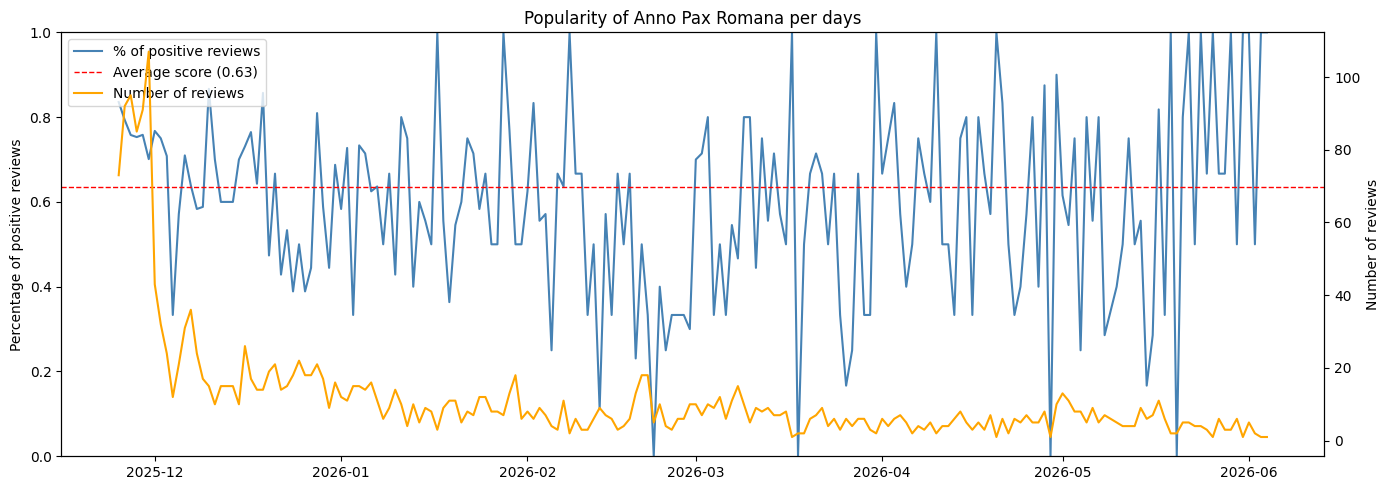

In [28]:
# Score mean and number of reviews per day
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['review_count'],
         color = 'orange',
         label = 'Number of reviews')
ax2.set_ylabel('Number of reviews')

# Global average as a horizontal reference line (on ax1, same 0-1 scale)
overall_avg = reviews['voted_up'].mean()
ax1.axhline(overall_avg, color='red', linestyle='--', linewidth=1,
            label=f'Average score ({overall_avg:.2f})')

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Popularity of Anno Pax Romana per days')
fig.tight_layout()
plt.show()



## Sentiment Analysis using VADER algorithm

In [29]:
# Definying a cleaning function before analysis

def clean_text(text):
    text = text.lower()                          # small leters
    text = re.sub(r'http\S+', '', text)          # removing links
    text = re.sub(r'[^\w\s]', '', text)          # removing punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # removing multiple spaces
    return text

reviews['clean_text'] = reviews['review_text'].apply(clean_text)

In [30]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
reviews['sentiment_score'] = reviews['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label'] = reviews['sentiment_score'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label']
))

              precision    recall  f1-score   support

           0       0.69      0.53      0.60       795
           1       0.76      0.86      0.81      1381

    accuracy                           0.74      2176
   macro avg       0.73      0.70      0.70      2176
weighted avg       0.73      0.74      0.73      2176



Text(0, 0.5, 'Percentege of positive sentiment labels')

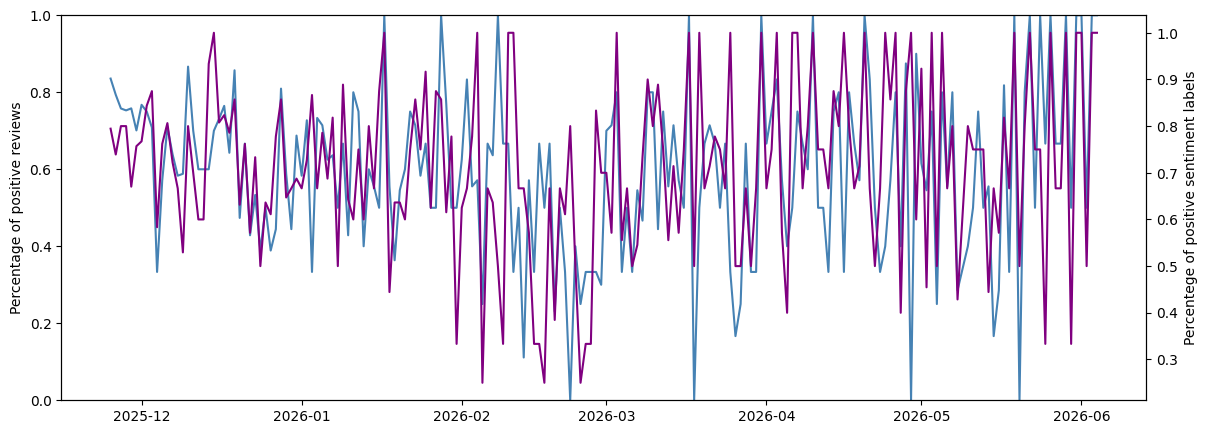

In [33]:
# Visual comparison of sentiment analysis
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    avg_sentiment = ('sentiment_label', 'mean')
).reset_index()

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['avg_sentiment'],
         color = 'purple',
         label = 'Sentiment label')
ax2.set_ylabel('Percentege of positive sentiment labels')



In [40]:
# TF-IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

df_pos = df[df["voted_up"] == True]["review_text"].dropna()
df_neg = df[df["voted_up"] == False]["review_text"].dropna()

def top_tfidf(corpus, n=20):
    vec = TfidfVectorizer(ngram_range=(3, 5), stop_words="english", max_features=5000)
    vec.fit_transform(corpus)
    scores = zip(vec.get_feature_names_out(), vec.idf_)
    return sorted(scores, key=lambda x: x[1])[:n]  # niższe IDF = częstsze

print("=== Pozytywne ===")
for term, score in top_tfidf(df_pos):
    print(f"  {term}")

print("\n=== Negatywne ===")
for term, score in top_tfidf(df_neg):
    print(f"  {term}")

=== Pozytywne ===
  117 pax romana
  anno 117 pax
  anno 117 pax romana
  like anno 1800
  good anno 1800
  compared anno 1800
  played anno 1800
  game anno 1800
  great anno game
  previous anno games
  better anno 1800
  city builder game
  city building games
  great city builder
  like anno games
  like city builders
  anno 1800 better
  anno 1800 dlc
  anno 1800 years
  liked anno 1800

=== Negatywne ===
  anno 1800 better
  game feels like
  anno 1800 game
  anno 1800 instead
  play anno 1800
  ve played anno
  117 pax romana
  1800 anno 117
  anno 117 pax
  anno 117 pax romana
  compared anno 1800
  don buy game
  like anno 1800
  love anno series
  anno 1800 anno
  anno 1800 anno 117
  anno 1800 way
  buy anno 1800
  campaign ends abruptly
  game breaking bug


In [42]:
!pip install keybert -q
from keybert import KeyBERT

kw_model = KeyBERT()

# Połącz wszystkie negatywne recenzje w jeden tekst
neg_text = " ".join(df[df["voted_up"] == False]["review_text"].dropna().tolist())

keywords = kw_model.extract_keywords(
    neg_text,
    keyphrase_ngram_range=(2, 4),  # frazy 2-4 słowne
    stop_words="english",
    top_n=20
)
for phrase, score in keywords:
    print(f"{score:.3f}  {phrase}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

KeyboardInterrupt: 

In [41]:
# LDA

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vec = CountVectorizer(ngram_range=(3, 4), stop_words="english",
                      max_features=3000, min_df=10)
X = vec.fit_transform(df["review_text"].dropna())

lda = LatentDirichletAllocation(n_components=8, random_state=42)
lda.fit(X)

feature_names = vec.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Temat {i+1}: {', '.join(top_words)}")

Temat 1: game anno 1800, anno 1800 dlc, anno 1800 just, anno 1800 like, compared anno 1800, played anno 1800, anno 1800 better, anno 1800 anno, better anno 1800, great city builder
Temat 2: like anno 1800, good anno 1800, anno 1800 like, great city builder, anno 1800 just, anno 1800 better, hours anno 1800, compared anno 1800, great anno game, game anno 1800
Temat 3: 117 pax romana, anno 117 pax romana, anno 117 pax, great city builder, like city builders, anno 1800 just, city building games, previous anno games, anno 1800 game, liked anno 1800
Temat 4: hours anno 1800, city building games, anno 1800 anno, like city builders, game feels like, good anno 1800, great anno game, compared anno 1800, anno 1800 game, anno 1800 just
Temat 5: ve played anno, liked anno 1800, played anno game, like city builders, played anno 1800, anno 1800 like, game feels like, anno 1800 game, anno 1800 better, anno 117 pax romana
Temat 6: played anno 1800, previous anno games, anno 1800 just, anno 1800 better